# J1.2 v3 — finer-grid contact preflight

Отчёт читает checksummed batch v3 с commit `9b5f237` и сравнивает его с остановленным v2. Между версиями изменены только `shape/spacing`; физическая геометрия, движения, textures, optimizer search и gates одинаковы. CUDA optimizer и held-out challenge здесь не запускаются.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

candidate = Path.cwd()
REPO_ROOT = candidate if (candidate / "configs").is_dir() else candidate.parent
RESULT_V2 = REPO_ROOT / "results/piecewise_svf_j12_contact_truth_preflight_v2"
RESULT_V3 = REPO_ROOT / "results/piecewise_svf_j12_contact_truth_preflight_v3"

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()

def load_batch(directory: Path):
    manifest_path = directory / "manifest.json"
    summary_path = directory / "summary.csv"
    assert manifest_path.is_file() and summary_path.is_file()
    return (
        json.loads(manifest_path.read_text(encoding="utf-8")),
        pd.read_csv(summary_path),
    )

manifest_v2, summary_v2 = load_batch(RESULT_V2)
manifest_v3, summary_v3 = load_batch(RESULT_V3)
print(f"v2: {manifest_v2['truth_pass_count']}/{manifest_v2['case_count']} PASS")
print(f"v3: {manifest_v3['truth_pass_count']}/{manifest_v3['case_count']} PASS")
print(f"v3 code: {manifest_v3['code_version']}")

v2: 0/3 PASS
v3: 3/3 PASS
v3 code: 9b5f2378fdc4c4668a55e953e37b3e1e4d7845fa


In [2]:
def verify(directory: Path, manifest: dict) -> dict[str, bool]:
    checks = {
        "suite": sha256(REPO_ROOT / "configs" / manifest["suite_config"]["path"])
        == manifest["suite_config"]["sha256"],
        "search": sha256(REPO_ROOT / "configs" / manifest["search_config"]["path"])
        == manifest["search_config"]["sha256"],
        "summary": sha256(directory / "summary.csv") == manifest["summary_sha256"],
    }
    for name, expected in manifest["diagnostic_sha256"].items():
        checks[name] = sha256(directory / name) == expected
    return checks

checks = {
    **{f"v2/{key}": value for key, value in verify(RESULT_V2, manifest_v2).items()},
    **{f"v3/{key}": value for key, value in verify(RESULT_V3, manifest_v3).items()},
}
assert all(checks.values()), checks
pd.Series(checks, name="checksum_match").to_frame()

,checksum_match
v2/suite,True
v2/search,True
v2/summary,True
v2/dev_contact_counter_rotation__surface.npz,True
v2/dev_contact_longitudinal_twist__surface.npz,True
v2/dev_contact_shallow_low_texture__surface.npz,True
v3/suite,True
v3/search,True
v3/summary,True
v3/dev_contact_counter_rotation__surface.npz,True


In [3]:
metrics = [
    "case_id",
    "analytic_abs_distance_p95_max_mm",
    "raster_abs_distance_p95_max_mm",
    "raster_surface_coverage_min",
    "lung_round_trip_p95_mm",
    "body_round_trip_p95_mm",
    "tangential_slip_median_mm",
    "lung_jacobian_p01",
    "body_jacobian_p01",
    "truth_gate_pass",
]
comparison = pd.concat(
    [summary_v2[metrics].assign(version="v2"), summary_v3[metrics].assign(version="v3")],
    ignore_index=True,
)
comparison.style.format({
    "analytic_abs_distance_p95_max_mm": "{:.6f}",
    "raster_abs_distance_p95_max_mm": "{:.3f}",
    "raster_surface_coverage_min": "{:.3f}",
    "lung_round_trip_p95_mm": "{:.4f}",
    "body_round_trip_p95_mm": "{:.4f}",
    "tangential_slip_median_mm": "{:.3f}",
    "lung_jacobian_p01": "{:.3f}",
    "body_jacobian_p01": "{:.3f}",
})

,case_id,analytic_abs_distance_p95_max_mm,raster_abs_distance_p95_max_mm,raster_surface_coverage_min,lung_round_trip_p95_mm,body_round_trip_p95_mm,tangential_slip_median_mm,lung_jacobian_p01,body_jacobian_p01,truth_gate_pass,version
0,dev_contact_counter_rotation,0.000643,0.848,0.922,0.0013,0.0007,3.053,1.156,1.156,False,v2
1,dev_contact_longitudinal_twist,0.000446,0.766,0.948,0.0011,0.0017,1.543,1.221,1.221,False,v2
2,dev_contact_shallow_low_texture,0.000124,0.753,0.949,0.0003,0.0001,1.339,1.074,1.074,False,v2
3,dev_contact_counter_rotation,0.000643,0.668,0.977,0.0013,0.0007,2.998,1.156,1.156,True,v3
4,dev_contact_longitudinal_twist,0.000445,0.640,0.983,0.0011,0.0017,1.527,1.221,1.221,True,v3
5,dev_contact_shallow_low_texture,0.000124,0.719,0.973,0.0003,0.0001,1.327,1.074,1.074,True,v3


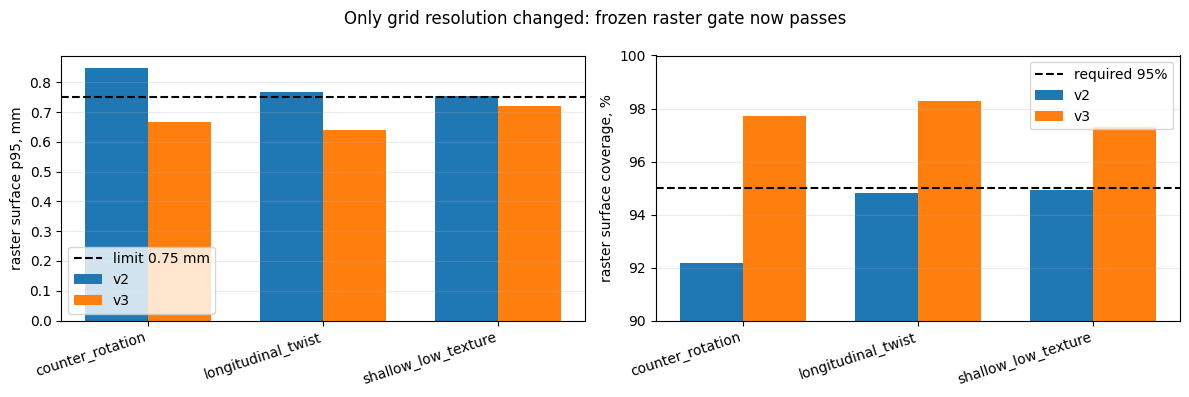

In [4]:
labels = summary_v3["case_id"].str.replace("dev_contact_", "", regex=False)
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(x - 0.18, summary_v2["raster_abs_distance_p95_max_mm"], 0.36, label="v2")
axes[0].bar(x + 0.18, summary_v3["raster_abs_distance_p95_max_mm"], 0.36, label="v3")
axes[0].axhline(0.75, color="black", linestyle="--", label="limit 0.75 mm")
axes[0].set_ylabel("raster surface p95, mm")
axes[0].set_xticks(x, labels, rotation=18, ha="right")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(x - 0.18, 100 * summary_v2["raster_surface_coverage_min"], 0.36, label="v2")
axes[1].bar(x + 0.18, 100 * summary_v3["raster_surface_coverage_min"], 0.36, label="v3")
axes[1].axhline(95, color="black", linestyle="--", label="required 95%")
axes[1].set_ylabel("raster surface coverage, %")
axes[1].set_xticks(x, labels, rotation=18, ha="right")
axes[1].set_ylim(90, 100)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
fig.suptitle("Only grid resolution changed: frozen raster gate now passes")
fig.tight_layout()
plt.show()

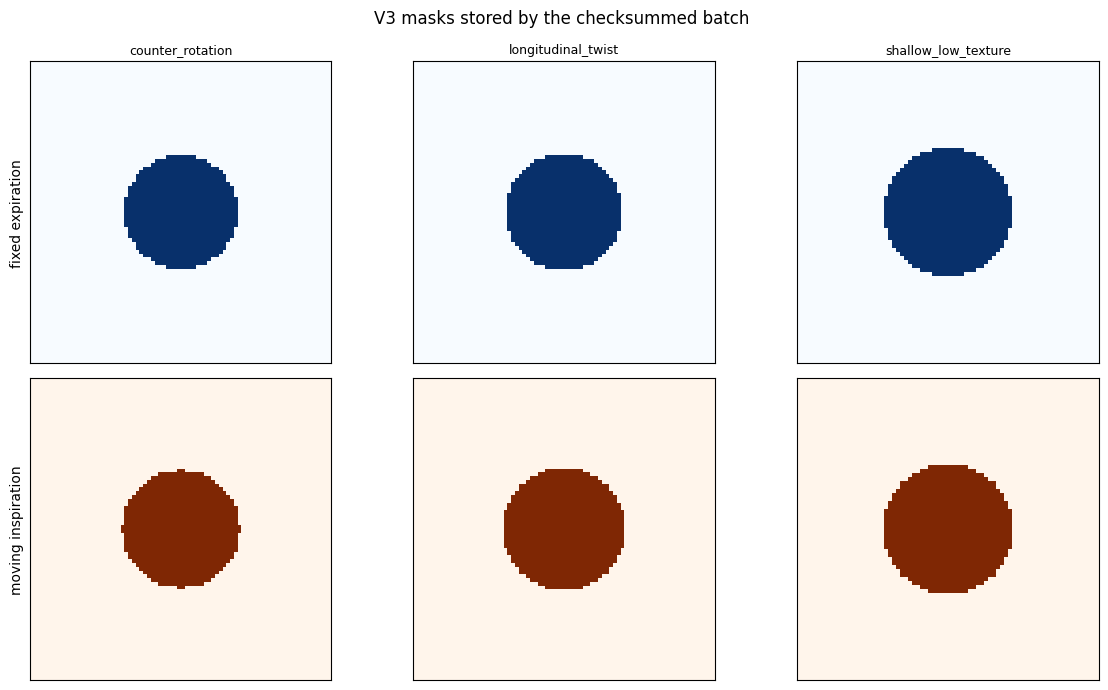

In [5]:
fig, axes = plt.subplots(2, len(summary_v3), figsize=(12, 7))
for column, row in enumerate(summary_v3.itertuples(index=False)):
    artifact = np.load(RESULT_V3 / f"{row.case_id}__surface.npz")
    fixed = artifact["fixed_lung_mask"]
    moving = artifact["moving_lung_mask"]
    z = fixed.shape[2] // 2
    axes[0, column].imshow(fixed[:, :, z].T, origin="lower", cmap="Blues")
    axes[1, column].imshow(moving[:, :, z].T, origin="lower", cmap="Oranges")
    axes[0, column].set_title(row.case_id.replace("dev_contact_", ""), fontsize=9)
    for axis in axes[:, column]:
        axis.set_aspect("equal")
        axis.set_xticks([])
        axis.set_yticks([])
axes[0, 0].set_ylabel("fixed expiration")
axes[1, 0].set_ylabel("moving inspiration")
fig.suptitle("V3 masks stored by the checksummed batch")
fig.tight_layout()
plt.show()

In [6]:
worst_p95 = summary_v3["raster_abs_distance_p95_max_mm"].max()
minimum_coverage = summary_v3["raster_surface_coverage_min"].min()
worst_analytic = summary_v3["analytic_abs_distance_p95_max_mm"].max()
assert manifest_v3["truth_pass_count"] == 3
assert manifest_v3["development_search_allowed"]
assert not manifest_v3["optimizer_started"]
assert not manifest_v3["challenge"]["loaded"]
print("J1.2 v3 EXACT-TRUTH PREFLIGHT PASS 3/3")
print(f"analytic worst p95={worst_analytic:.6f} mm")
print(f"raster worst p95={worst_p95:.3f} mm; min coverage={100 * minimum_coverage:.1f}%")
print("optimizer remains not started; challenge remains closed")
print("next allowed action: frozen 3 variants × 3 development cases optimizer search")

J1.2 v3 EXACT-TRUTH PREFLIGHT PASS 3/3
analytic worst p95=0.000643 mm
raster worst p95=0.719 mm; min coverage=97.3%
optimizer remains not started; challenge remains closed
next allowed action: frozen 3 variants × 3 development cases optimizer search
